# K-최근접 이웃 (K-Nearest Neighbors, KNN)

## 1. KNN이란?
K-최근접 이웃 알고리즘은 **"가장 가까운 이웃들을 보고 판단한다"** 는 아주 직관적인 아이디어에 기반한 모델이다.    
새로운 데이터가 들어오면 기존 학습 데이터 중에서 **거리가 가장 가까운 k개의 데이터**를 찾고 그 이웃들을 기준으로 결과를 결정한다.

- **분류(Classification)**: 이웃 k개 중 **다수결**로 클래스를 결정
- **회귀(Regression)**: 이웃 k개의 **타깃값 평균**으로 예측값을 결정

## 2. 핵심 하이퍼파라미터 - n_neighbors (k)
- k값은 참고할 이웃의 개수를 의미한다.
- k가 **작으면** → 모델이 너무 민감해져서 노이즈에 흔들리기 쉽다 (과대적합 경향)
- k가 **크면** → 너무 많은 이웃을 참고해서 경계가 뭉뚱그려진다 (과소적합 경향)
- 적절한 k값은 데이터 특성에 따라 실험을 통해 찾아야 한다.

## 3. 거리 계산과 스케일 문제
KNN은 이웃을 찾을 때 **거리(주로 유클리드 거리)** 기준으로 삼는다.    
따라서 특성(feature)들의 **범위(scale)가 서로 다르면** 값이 큰 특성이 거리 계산을 지배하게 되어 실제로는 중요한 특성이 무시되는 문제가 생긴다.

> 예: 길이(cm)와 무게(g)를 함께 사용할 때 무게의 숫자 범위가 훨씬 크면 거리 계산이 무게 위주로 왜곡된다.

**해결 방법**: 표준화(Standardization) 등으로 특성 스케일을 맞춰준 뒤 거리를 계산해야 한다.

## 4. KNN 회귀와 가중치 방식
`KNeighborsRegressor`는 기본적으로 이웃 k개의 **단순 평균(uniform)** 으로 예측값을 계산한다.
`weights='distance'` 옵션을 주면 거리가 가까운 이웃에게 더 높은 가중치를 부여할 수도 있다.

## 5. KNN의 한계
1. **스케일 민감성**: 특성 간 범위 차이가 크면 잘못된 이웃을 선택하게 되어 예측/분류 성능이 떨어진다.
2. **외삽(extrapolation) 불가**
    - KNN은 패턴을 수식으로 "학습"하는 것이 아니라 가장 가까운 데이터를 찾아 평균을 내는 방식이다.
    - 따라서 **학습 데이터의 범위를 벗어난 값은 예측하지 못한다.**
    - 예: 훈련 데이터의 타깃값이 100g~500g 범위에만 있다면 실제로 1kg짜리 데이터를 넣어도 모델은 여전히 훈련 데이터 내에서 가장 가까운(=가장 무거운) 이웃들의 평균값을 출력한다.
    - 즉, 1kg에 가까운 값을 예측하지 못하고 훈련 데이터 범위 안의 값으로 결과가 제한된다.
    
---
   
*참고: 『혼자 공부하는 머신러닝+딥러닝』(한빛미디어) 학습 내용을 바탕으로 직접 정리함*

# n_neighbors 실습하기 (iris Data)

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import pandas as pd

# 붓꽃 데이터셋 로드
iris = load_iris()
X = iris.data  # 꽃받침 길이/너비, 꽃잎 길이/너비
y = iris.target  # 품종 (0, 1, 2)

# 데이터 간단히 확인
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [2]:
# 훈련/테스트 데이터 분리하기
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=42, stratify=y)

print(f"훈련 데이터 개수: {len(X_train)}")
print(f"테스트 데이터 개수: {len(y_train)}")

훈련 데이터 개수: 120
테스트 데이터 개수: 120


In [3]:
# n_neighbors 값을 바꿔가며 정확도 비교

from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 7, 9, 15, 21]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    score = knn.score(X_test, y_test)
    accuracies.append(score)
    print(f"k={k} → 정확도: {score:.4f}")

k=1 → 정확도: 0.9667
k=3 → 정확도: 1.0000
k=5 → 정확도: 1.0000
k=7 → 정확도: 0.9667
k=9 → 정확도: 1.0000
k=15 → 정확도: 0.9667
k=21 → 정확도: 0.9333


In [5]:
# 한글 인코딩 설정

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

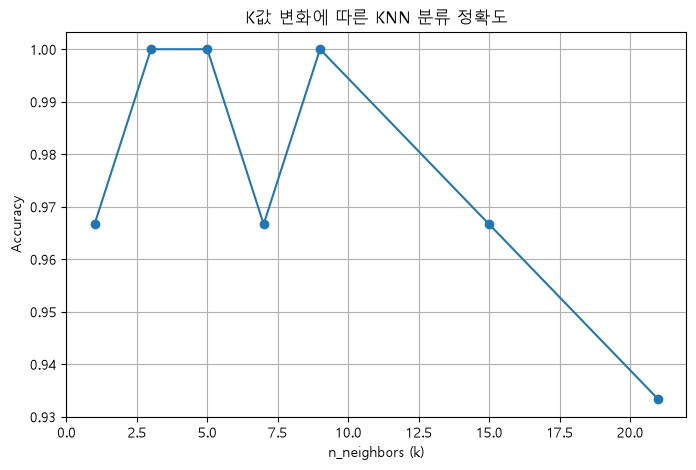

In [6]:
# k값에 따른 정확도 시각화

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('n_neighbors (k)')
plt.ylabel('Accuracy')
plt.title('K값 변화에 따른 KNN 분류 정확도')
plt.grid(True)
plt.show()

### 실습 결과 해석

- k값을 1~21까지 바꿔가며 테스트한 결과, k=3, 5, 9에서 정확도 1.0000으로 가장 높게 나타났다.
- k=1처럼 너무 작으면 이웃 하나의 노이즈에 민감하게 반응해 정확도가 떨어졌다.
- k=15, 21처럼 너무 크면 다른 클래스의 데이터까지 이웃으로 포함되어 오히려 정확도가 낮아지는 것을 확인할 수 있었다.
- 다만 테스트 데이터가 30개로 크지 않아, 여러 k값(3~9)이 동일하게 100% 정확도를 보인 것은 우연의 영향일 수 있다.
- 하나의 train/test 분할만으로 최적 k를 단정하기보다는 추후 교차 검증(cross-validation)을 활용해 더 안정적으로 검증해볼 필요가 있다.

# train score와 test score

In [7]:
# train score와 test score를 비교해보기

train_scores = []
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_scores.append(knn.score(X_train, y_train))
    test_scores.append(knn.score(X_test, y_test))
    print(f"k={k} → train: {train_scores[-1]:.4f}, test: {test_scores[-1]:.4f}")

k=1 → train: 1.0000, test: 0.9667
k=3 → train: 0.9583, test: 1.0000
k=5 → train: 0.9667, test: 1.0000
k=7 → train: 0.9750, test: 0.9667
k=9 → train: 0.9750, test: 1.0000
k=15 → train: 0.9750, test: 0.9667
k=21 → train: 0.9750, test: 0.9333


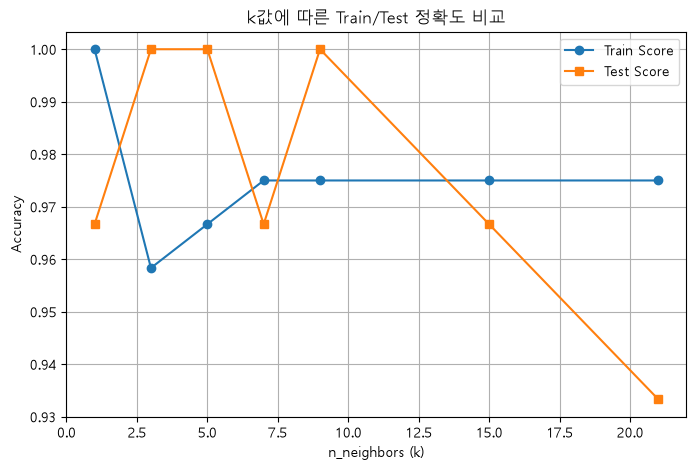

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_scores, marker='o', label='Train Score')
plt.plot(k_values, test_scores, marker='s', label='Test Score')
plt.xlabel('n_neighbors (k)')
plt.ylabel('Accuracy')
plt.title('k값에 따른 Train/Test 정확도 비교')
plt.legend()
plt.grid(True)
plt.show()

### Train/Test Score를 통한 과대·과소적합 판단

k값별 train/test score를 비교한 결과, 아래와 같은 패턴을 확인할 수 있었다.

- **k=1**: train score 1.0000, test score 0.9667로 train과 test 간 격차가 발생했다.
  훈련 데이터를 거의 그대로 암기하듯 예측하는 전형적인 **과대적합** 신호로 볼 수 있다.

- **k=3~9**: train score는 0.958~0.975 수준으로 낮아졌지만, test score는 오히려 1.0000으로
  가장 높게 나타났다. train과 test 간 격차도 크지 않아, 이 구간이 과대적합과 과소적합 사이에서
  **가장 균형 잡힌 지점**이라고 판단할 수 있다.

- **k=15, 21**: train score는 0.9750으로 유지되지만 test score는 각각 0.9667, 0.9333으로
  점점 낮아진다. train score는 더 이상 개선되지 않는 채로 test score만 하락하는 것은
  이웃을 지나치게 많이 참고해 다른 클래스의 데이터까지 섞여 들어가는 **과소적합** 신호이다.

**결론**:     
단순히 test score가 가장 높은 k 하나를 고르기보다 train/test 격차가 작으면서 test score도 안정적으로 높은 **k=3~9 구간**을 적정 범위로 선택하는 것이 더 타당하다.    
이번 실습을 통해 k값이 모델의 편향-분산(bias-variance) 트레이드오프에 직접적인 영향을 준다는 것을 수치로 확인할 수 있었다.

# 스케일 문제 실험

In [9]:
# wine 데이터 불러오기 & 스케일 확인

from sklearn.datasets import load_wine

wine = load_wine()
X_wine = wine.data
y_wine = wine.target

df_wine = pd.DataFrame(X_wine, columns=wine.feature_names)
df_wine.describe().loc[['min', 'max']]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
min,11.03,0.74,1.36,10.6,70.0,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.0
max,14.83,5.80,3.23,30.0,162.0,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.0


- 데이터 확인 결과 'alcohol'은 11 ~ 15인데 'proline'은 278 ~ 1680 정도로 특성 범위가 크게 다르다.

In [10]:
# train/test 분리
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

In [11]:
# 표준화 전 - KNN 정확도
knn_before = KNeighborsClassifier(n_neighbors=5)
knn_before.fit(X_train_w, y_train_w)
score_before = knn_before.score(X_test_w, y_test_w)

print(f"표준화 전 정확도: {score_before:.4f}")

표준화 전 정확도: 0.8056


In [12]:
# 표준화 후 - KNN 정확도
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train_w)  # 훈련 데이터 기준으로만 fit

X_train_scaled = scaler.transform(X_train_w)
X_test_scaled = scaler.transform(X_test_w)  # 테스트도 같은 기준으로 변환

knn_after = KNeighborsClassifier(n_neighbors=5)
knn_after.fit(X_train_scaled, y_train_w)
score_after = knn_after.score(X_test_scaled, y_test_w)

print(f"표준화 후 정확도: {score_after:.4f}")

표준화 후 정확도: 0.9722


- 여기서 중요했던 포인트는 scaler.fit()은 **훈련 데이터만 적용** 하고, 테스트 데이터는 transform()만 해야한다.
- 테스트 데이터로도 fit()을 하는 경우에는 **미래 정보를 미리 안다** 는 데이터 누수 (data leakage) 문제가 발생한다.

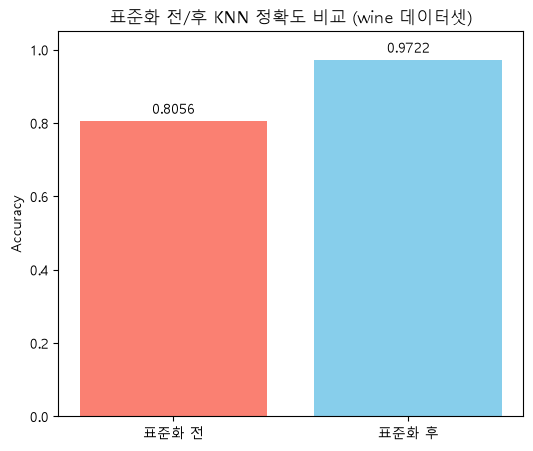

In [13]:
# 결과 비교 시각화

plt.figure(figsize=(6, 5))
plt.bar(['표준화 전', '표준화 후'], [score_before, score_after], color=['salmon', 'skyblue'])
plt.ylabel('Accuracy')
plt.title('표준화 전/후 KNN 정확도 비교 (wine 데이터셋)')
plt.ylim(0, 1.05)
for i, v in enumerate([score_before, score_after]):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center')
plt.show()

### 스케일(Scale) 문제 실험 - 표준화 전/후 비교

KNN은 거리 기반으로 이웃을 찾기 때문에, 특성(feature)마다 값의 범위가 다르면    
값이 큰 특성이 거리 계산을 지배하게 되어 왜곡된 결과가 나올 수 있다.    
이를 직접 확인하기 위해 wine 데이터셋을 사용했다.    

wine 데이터셋은 `alcohol`(11-15 범위)과 `proline`(278~1680 범위)처럼    
특성 간 값의 범위 차이가 매우 크다는 특징이 있다. 이런 상태로 거리를 계산하면    
proline처럼 절대값이 큰 특성이 실제 중요도와 무관하게 거리 계산을 좌우하게 된다.

### 실험 결과
**표준화 전 : 0.8056**    
**표준화 후 : 0.9722**    
    
표준화(StandardScaler)를 적용해 모든 특성을 평균 0, 분산 1 기준으로 맞춰준 결과 정확도가 0.8056 → 0.9722로 큰 폭으로 개선되었다.     
이는 표준화 전에는 proline처럼 값의 범위가 큰 특성에 거리 계산이 편향되어 있었고,     
실제로 분류에 중요한 다른 특성들의 영향력이 상대적으로 묻혀 있었다는 것을 보여준다.

### 결론
KNN처럼 거리 기반으로 동작하는 모델은 특성 간 스케일 차이에 매우 민감하며     
표준화와 같은 전처리 과정이 모델 성능에 직접적인 영향을 미친다는 것을 실험을 통해 확인할 수 있었다.

# KNN 회귀 실습

In [14]:
# 당뇨병 데이터 불러오기

from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
X_d = diabetes.data
y_d = diabetes.target  # 1년 후 당뇨병 진행 정도 (수치가 클수록 진행됨)

df_d = pd.DataFrame(X_d, columns=diabetes.feature_names)
df_d['target'] = y_d
df_d.describe().loc[['min', 'max']]

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
min,-0.107226,-0.044642,-0.090275,-0.112399,-0.126781,-0.115613,-0.102307,-0.076395,-0.126097,-0.137767,25.0
max,0.110727,0.050680,0.170555,0.132044,0.153914,0.198788,0.181179,0.185234,0.133597,0.135612,346.0


In [15]:
# train/test 분리 및 KNN 회귀 모델 학습

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42
)

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_d, y_train_d)

print(f"train score (R²): {knn_reg.score(X_train_d, y_train_d):.4f}")
print(f"test score (R²): {knn_reg.score(X_test_d, y_test_d):.4f}")

train score (R²): 0.5839
test score (R²): 0.4302


> 위 회귀에서 .score()는 정확도가 아니라  **R² (결정계수)이다.**    
> 1에 가까울수록 예측이 잘 맞으며 분류의 정확도와는 다른 지표이다.

In [16]:
# 실제 예측값 vs 정답 비교 (일부 샘플)
y_pred = knn_reg.predict(X_test_d)

for i in range(5):
    print(f"실제값: {y_test_d[i]:.1f}, 예측값: {y_pred[i]:.1f}")

실제값: 219.0, 예측값: 125.6
실제값: 70.0, 예측값: 160.2
실제값: 202.0, 예측값: 153.0
실제값: 230.0, 예측값: 238.0
실제값: 111.0, 예측값: 153.4


In [17]:
# 외삽(extrapolation) 한계 실험
print(f"훈련 데이터 target 범위: {y_train_d.min():.1f} ~ {y_train_d.max():.1f}")

# 테스트 데이터 중 '가장 극단적인' 특성 조합을 하나 골라서
# 각 특성값에 인위적으로 큰 배율을 곱해 극단적인 입력을 만든다
import numpy as np

extreme_sample = X_test_d[0:1] * 3  # 특성값을 3배로 부풀린 극단적 입력
extreme_pred = knn_reg.predict(extreme_sample)

print(f"극단적으로 부풀린 입력에 대한 예측값: {extreme_pred[0]:.1f}")
print(f"→ 훈련 데이터 target 최댓값({y_train_d.max():.1f})을 벗어나지 못하는지 확인")

훈련 데이터 target 범위: 25.0 ~ 346.0
극단적으로 부풀린 입력에 대한 예측값: 162.8
→ 훈련 데이터 target 최댓값(346.0)을 벗어나지 못하는지 확인


## KNN 회귀 - 외삽(Extrapolation) 한계 실험

훈련 데이터의 target(당뇨병 진행도) 범위는 25.0 ~ 346.0이었다.    
이 범위를 벗어나는 예측이 가능한지 확인하기 위해 테스트 데이터 중 하나의 특성값을    
인위적으로 3배 부풀려 극단적인 입력을 만들어 예측을 시도했다.

### 실험 결과
- 훈련 데이터 target 범위: 25.0 ~ 346.0
- 극단적으로 부풀린 입력에 대한 예측값: 162.8

특성값을 3배나 부풀렸음에도 예측값은 여전히 훈련 데이터의 target 범위(25.0~346.0) 안에 머물렀다.    
이는 KNN이 실제로 패턴을 수식으로 학습하는 것이 아니라, 특성 공간에서 가장 가까운 이웃들을 찾아 그들의 target 평균을 내는 방식이기 때문이다.    
아무리 입력 특성이 극단적이어도 결국 "훈련 데이터 중 가장 가까운 몇 개"를 참고할 수밖에 없으므로 예측값은 훈련 데이터 target 범위를 벗어날 수 없다.    
     
참고로 예측값(162.8)이 최댓값(346.0)에 가깝게 나오지 않은 이유는    
부풀린 입력과 특성 공간상 가장 가까운 이웃들이 반드시 target이 가장 큰 데이터라는 보장이 없기 때문이다.     
이번 실험의 핵심은 "예측값이 최댓값에 가까운가"가 아니라,    
**"입력을 아무리 극단적으로 바꿔도 예측값이 훈련 데이터 범위를 벗어나지 못한다"** 는사실을 확인하는 데 있으며 실험 결과는 이를 명확히 뒷받침한다.
    
### 결론
KNN은 훈련 데이터에 없는 새로운 패턴(범위 밖의 값)을 예측하는 데는 근본적인 한계가 있다.    
이는 선형회귀처럼 수식(직선/곡선)으로 관계를 학습하는 모델과 대비되는 KNN의 특징이며,     
다음 학습 주제인 선형회귀에서 이 차이를 비교해볼 필요가 있다.